In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv('Train Set.csv')
test = pd.read_csv('Test Set.csv')
usmetros = pd.read_csv('usmetros.csv')

In [3]:
usmetros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   metro_fips   387 non-null    int64  
 1   metro        387 non-null    object 
 2   metro_ascii  387 non-null    object 
 3   metro_full   387 non-null    object 
 4   county_name  387 non-null    object 
 5   county_fips  387 non-null    int64  
 6   state_id     387 non-null    object 
 7   state_name   387 non-null    object 
 8   lat          387 non-null    float64
 9   lng          387 non-null    float64
 10  population   387 non-null    int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 33.4+ KB


In [4]:
usmetros.head()

,metro_fips,metro,metro_ascii,metro_full,county_name,county_fips,state_id,state_name,lat,lng,population
0,35620,New York,New York,"New York-Newark-Jersey City, NY-NJ",Suffolk,36103,NY,New York,40.7222,-74.0225,19940274
1,31080,Los Angeles,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles,6037,CA,California,34.2215,-118.1494,12927614
2,16980,Chicago,Chicago,"Chicago-Naperville-Elgin, IL-IN",Cook,17031,IL,Illinois,41.6675,-87.9597,9406924
3,19100,Dallas,Dallas,"Dallas-Fort Worth-Arlington, TX",Denton,48121,TX,Texas,32.8495,-96.9704,8344032
4,26420,Houston,Houston,"Houston-Pasadena-The Woodlands, TX",Harris,48201,TX,Texas,29.8422,-95.3855,7796182


In [5]:
train.head(5)

,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,...,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full
0,2012-03-31,46550.0,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,...,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,Atlanta-Sandy Springs-Alpharetta
1,2012-03-31,200000.0,7500.0,104.931794,79.265873,1.0,1.0,1.0,2.0,290.0,...,1108.0,641.0,94600.0,1171.0,52.0,2376.0,2376.0,1018.0,105863.681174,Pittsburgh
2,2012-03-31,75750.0,92400.0,165.898618,63.412698,2.0,2.0,4.0,13.0,193.0,...,1252.0,627.0,62800.0,894.0,30.0,2106.0,2106.0,807.0,60152.096646,Pittsburgh
3,2012-03-31,79900.0,79900.0,0.696203,0.000000,1.0,1.0,1.0,1.0,46.0,...,208.0,534.0,66200.0,216.0,7.0,414.0,414.0,208.0,44042.242632,Pittsburgh
4,2012-03-31,196000.0,198000.0,122.807018,124.060150,1.0,1.0,1.0,1.0,49.0,...,692.0,484.0,79300.0,711.0,61.0,1489.0,1489.0,641.0,126572.277873,Pittsburgh


In [6]:
usmetros.head()

,metro_fips,metro,metro_ascii,metro_full,county_name,county_fips,state_id,state_name,lat,lng,population
0,35620,New York,New York,"New York-Newark-Jersey City, NY-NJ",Suffolk,36103,NY,New York,40.7222,-74.0225,19940274
1,31080,Los Angeles,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles,6037,CA,California,34.2215,-118.1494,12927614
2,16980,Chicago,Chicago,"Chicago-Naperville-Elgin, IL-IN",Cook,17031,IL,Illinois,41.6675,-87.9597,9406924
3,19100,Dallas,Dallas,"Dallas-Fort Worth-Arlington, TX",Denton,48121,TX,Texas,32.8495,-96.9704,8344032
4,26420,Houston,Houston,"Houston-Pasadena-The Woodlands, TX",Harris,48201,TX,Texas,29.8422,-95.3855,7796182


In [7]:
train['city_full'].value_counts().head(5)

city_full
New York-Newark-Jersey City       78020
Chicago-Naperville-Elgin          35344
Los Angeles-Long Beach-Anaheim    33840
Philadelphia-Camden-Wilmington    31396
DC_Metro                          29516
Name: count, dtype: int64

In [8]:
usmetros['metro_full'].value_counts().head(5)

metro_full
Carson City, NV                       1
New York-Newark-Jersey City, NY-NJ    1
Los Angeles-Long Beach-Anaheim, CA    1
Pocatello, ID                         1
Fairbanks-College, AK                 1
Name: count, dtype: int64

In [9]:
#### Mapping Cities

city_mapping = {
    'Las Vegas-Henderson-Paradise': 'Las Vegas-Henderson-North Las Vegas',
    'Denver-Aurora-Lakewood': 'Denver-Aurora-Centennial',
    'Houston-The Woodlands-Sugar Land': 'Houston-Pasadena-The Woodlands',
    'Austin-Round Rock-Georgetown': 'Austin-Round Rock-San Marcos',
    'Miami-Fort Lauderdale-Pompano Beach': 'Miami-Fort Lauderdale-West Palm Beach',
    'San Francisco-Oakland-Berkeley': 'San Francisco-Oakland-Fremont',
    'DC_Metro': 'Washington-Arlington-Alexandria',
    'Atlanta-Sandy Springs-Alpharetta': 'Atlanta-Sandy Springs-Roswell'
}

In [10]:
def clean_and_merge(df: pd.DataFrame, usmetros = usmetros) -> pd.DataFrame:
    # 1. Clean the city strings: "Atlanta-Sandy Springs..." -> "Atlanta"
    # This splits by hyphen and takes the first part
    df["city_clean"] = df["city_full"].str.split('-').str[0].str.strip()
    
    # 2. Also clean the usmetros lookup to be safe
    usmetros_clean = usmetros.copy()
    usmetros_clean["metro_clean"] = usmetros_clean["metro_full"].str.split('-').str[0].str.strip()
    
    # 3. Merge on the cleaned names
    df = df.merge(
        usmetros_clean[["metro_clean", "lat", "lng"]].drop_duplicates("metro_clean"),
        how="left",
        left_on="city_clean",
        right_on="metro_clean"
    )
    
    # Cleanup extra columns
    df.drop(columns=["city_clean", "metro_clean"], inplace=True)
    
    # Check for remaining misses
    missing = df[df["lat"].isnull()]["city_full"].unique()
    if len(missing) > 0:
        print(f"⚠️ Still missing: {missing}")
        df = df.dropna(subset=["lat", "lng"]) # Prevents the RuntimeWarning
        
    return df

In [11]:
train_df = clean_and_merge(train)
test_df = clean_and_merge(test)

⚠️ Still missing: ['Pittsburgh' 'St. Louis' 'Cincinnati' 'DC_Metro']
⚠️ Still missing: ['Cincinnati' 'St. Louis' 'DC_Metro' 'Pittsburgh']


In [12]:
train_df.head()

,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,...,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng
0,2012-03-31,46550.0,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,...,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,Atlanta-Sandy Springs-Alpharetta,33.7338,-84.3922
5,2012-03-31,340000.0,349900.0,171.817343,242.367722,13.0,18.0,30.0,54.0,126.0,...,419600.0,3207.0,147.0,5982.0,5982.0,2794.0,352711.838012,Boston-Cambridge-Newton,42.5584,-71.1007
9,2012-03-31,259750.0,284950.0,141.977239,166.023273,14.0,26.0,32.0,47.0,107.0,...,337800.0,4928.0,305.0,7923.0,7923.0,4319.0,281869.800260,Boston-Cambridge-Newton,42.5584,-71.1007
13,2012-03-31,364000.0,349900.0,134.366391,181.914518,5.0,9.0,19.0,35.0,217.0,...,440300.0,2947.0,131.0,4994.0,4994.0,2593.0,324802.060960,Boston-Cambridge-Newton,42.5584,-71.1007
18,2012-03-31,270000.0,344900.0,137.327354,141.493195,12.0,12.0,24.0,35.0,145.0,...,327400.0,3013.0,99.0,4775.0,4775.0,2722.0,267980.936958,Boston-Cambridge-Newton,42.5584,-71.1007


In [13]:
duplicated_rows = train_df[train_df.duplicated()].shape[0]

print("duplicated_rows:", duplicated_rows)

duplicated_rows = train_df[train_df.duplicated(subset=train_df.columns.difference(['date', 'year']))].shape[0]
print("duplicated_rows excluding date column:", duplicated_rows)


duplicated_rows: 0
duplicated_rows excluding date column: 2965


In [14]:
#Delete duplicates
train_df = train_df.drop_duplicates(subset=train_df.columns.difference(['date', 'year']), keep=False)

print(train_df.shape)

duplicated_rows = train_df[train_df.duplicated()].shape[0]
print("duplicated_rows:", duplicated_rows)

duplicated_rows = train_df[train_df.duplicated(subset=train_df.columns.difference(['date', 'year']))].shape[0]
print("duplicated_rows excluding date column:", duplicated_rows)

(490131, 41)
duplicated_rows: 0
duplicated_rows excluding date column: 0


In [15]:
duplicated_rows = test_df[test_df.duplicated()].shape[0]

print("duplicated_rows:", duplicated_rows)

duplicated_rows = test_df[test_df.duplicated(subset=test_df.columns.difference(['date', 'year']))].shape[0]
print("duplicated_rows excluding date column:", duplicated_rows)

duplicated_rows: 0
duplicated_rows excluding date column: 297


In [16]:
# Delete duplicates
test_df = test_df.drop_duplicates(subset=test_df.columns.difference(['date', 'year']), keep=False)

print(test_df.shape)

duplicated_rows = test_df[test_df.duplicated()].shape[0]
print("duplicated_rows:", duplicated_rows)

duplicated_rows = test_df[test_df.duplicated(subset=test_df.columns.difference(['date', 'year']))].shape[0]
print("duplicated_rows excluding date column:", duplicated_rows)

(125751, 41)
duplicated_rows: 0
duplicated_rows excluding date column: 0


In [17]:
###Clean_Outliers

train_df['median_list_price'].describe()

count    4.901310e+05
mean     3.892665e+05
std      4.289220e+05
min      0.000000e+00
25%      1.889000e+05
50%      2.920000e+05
75%      4.549750e+05
max      2.780000e+07
Name: median_list_price, dtype: float64

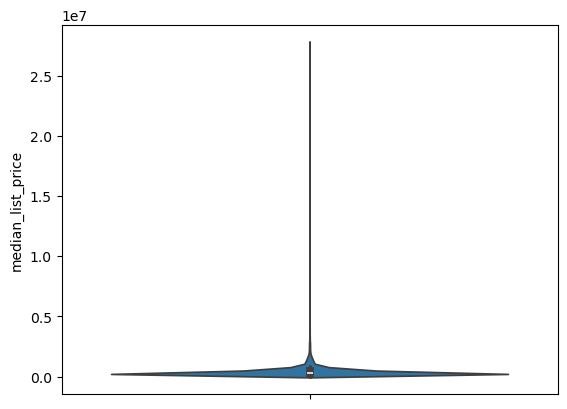

In [18]:
sns.violinplot( y = 'median_list_price', data = train_df)
plt.show()

In [19]:
top_1 = train_df.nlargest(int(0.01 * len(train_df)), 'median_list_price')
print (top_1.shape)
top_1.head(10)

(4901, 41)


,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,...,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng
284664,2015-12-31,830000.0,27800000.0,459.833795,3677.735150,3.0,3.0,1.0,22.0,235.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.366853e+06,New York-Newark-Jersey City,40.7222,-74.0225
300938,2016-03-31,4050000.0,19990000.0,613.636364,2815.492958,2.0,2.0,1.0,4.0,183.0,...,2000001.0,167.0,0.0,415.0,415.0,128.0,3.632048e+06,New York-Newark-Jersey City,40.7222,-74.0225
308616,2016-04-30,4050000.0,19990000.0,613.636364,2815.492958,2.0,2.0,1.0,4.0,183.0,...,2000001.0,167.0,0.0,415.0,415.0,128.0,3.663367e+06,New York-Newark-Jersey City,40.7222,-74.0225
316874,2016-05-31,4050000.0,19990000.0,613.636364,2815.492958,2.0,2.0,1.0,4.0,183.0,...,2000001.0,167.0,0.0,415.0,415.0,128.0,3.678078e+06,New York-Newark-Jersey City,40.7222,-74.0225
323186,2016-06-30,4050000.0,19990000.0,613.636364,2815.492958,2.0,2.0,1.0,4.0,183.0,...,2000001.0,167.0,0.0,415.0,415.0,128.0,3.675063e+06,New York-Newark-Jersey City,40.7222,-74.0225
328461,2016-07-31,4050000.0,19990000.0,613.636364,2815.492958,2.0,2.0,1.0,4.0,183.0,...,2000001.0,167.0,0.0,415.0,415.0,128.0,3.673641e+06,New York-Newark-Jersey City,40.7222,-74.0225
335971,2016-08-31,4050000.0,19990000.0,613.636364,2815.492958,2.0,2.0,1.0,4.0,183.0,...,2000001.0,167.0,0.0,415.0,415.0,128.0,3.672669e+06,New York-Newark-Jersey City,40.7222,-74.0225
337661,2016-09-30,4050000.0,19990000.0,613.636364,2815.492958,2.0,2.0,1.0,4.0,183.0,...,2000001.0,167.0,0.0,415.0,415.0,128.0,3.657950e+06,New York-Newark-Jersey City,40.7222,-74.0225
343952,2016-10-31,4050000.0,19990000.0,613.636364,2815.492958,2.0,2.0,1.0,4.0,183.0,...,2000001.0,167.0,0.0,415.0,415.0,128.0,3.634364e+06,New York-Newark-Jersey City,40.7222,-74.0225
351799,2016-11-30,4050000.0,19990000.0,613.636364,2815.492958,2.0,2.0,1.0,4.0,183.0,...,2000001.0,167.0,0.0,415.0,415.0,128.0,3.623836e+06,New York-Newark-Jersey City,40.7222,-74.0225


In [20]:
top_1 = train_df.nlargest(int(0.01 * len(train_df)), 'median_list_price')
print(top_1['median_list_price'].value_counts().sort_index(ascending=False))

median_list_price
27800000.0     1
19990000.0    38
15849000.0     1
15624500.0     3
15500000.0     1
              ..
1838000.0      1
1837500.0      5
1837000.0      5
1836750.0      1
1836500.0      2
Name: count, Length: 1431, dtype: int64


In [21]:
# Clean outliers above 19M in both train and eval
train_df = train_df[train_df['median_list_price'] <= 19_000_000].copy()
test_df = test_df[test_df['median_list_price'] <= 19_000_000].copy()

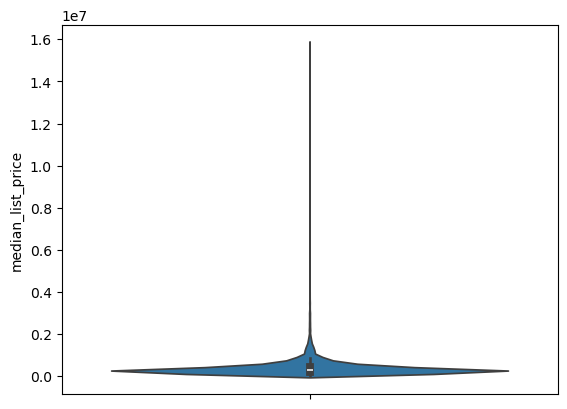

In [22]:
sns.violinplot( y = 'median_list_price', data = train_df)
plt.show()

In [23]:
train_df.to_csv('Cleaned_Train.csv',index = False)
test_df.to_csv('Cleaned_Test.csv', index = False)

In [24]:
df = train_df

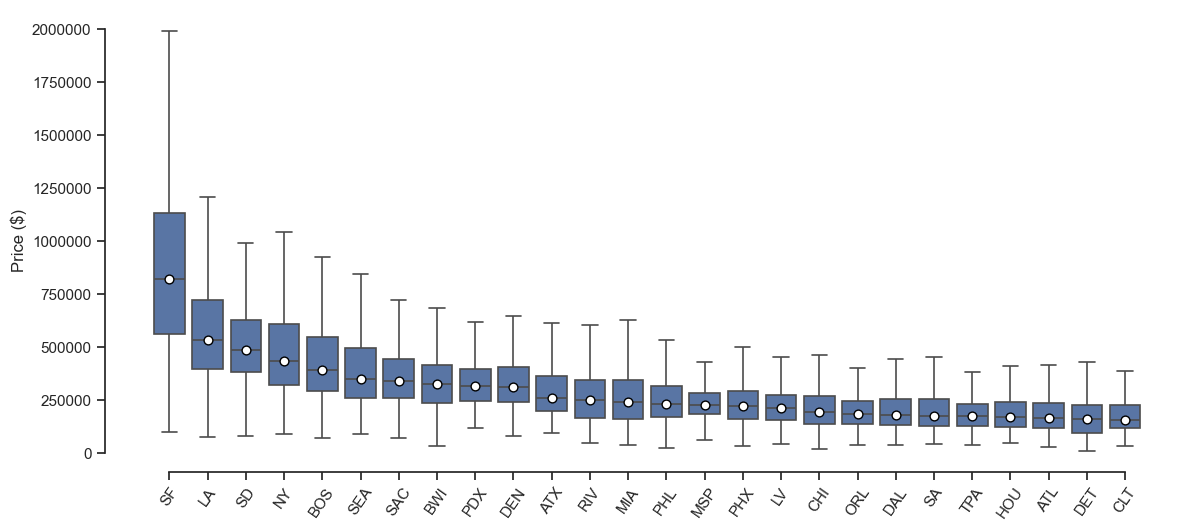

In [25]:
top_cities = df["city"].value_counts().head(30).index.tolist()
df_city    = df[df["city"].isin(top_cities)]
city_order = (
    df_city.groupby("city")["price"]
           .median()
           .sort_values(ascending=False)
           .index
)

sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    x="city", y="price", data=df_city,
    order=city_order, showfliers=False,
    linewidth=1.2, ax=ax
)

medians = df_city.groupby("city")["price"].median().loc[city_order]
for tick, median in enumerate(medians):
    ax.scatter(tick, median, color="white", edgecolor="black", zorder=5, s=40)

ax.set_xlabel("")
ax.set_ylabel("Price ($)")
ax.tick_params(axis="x", rotation=55)
sns.despine(trim=True)
ax.grid(False)
ax.ticklabel_format(axis="y", style="plain")

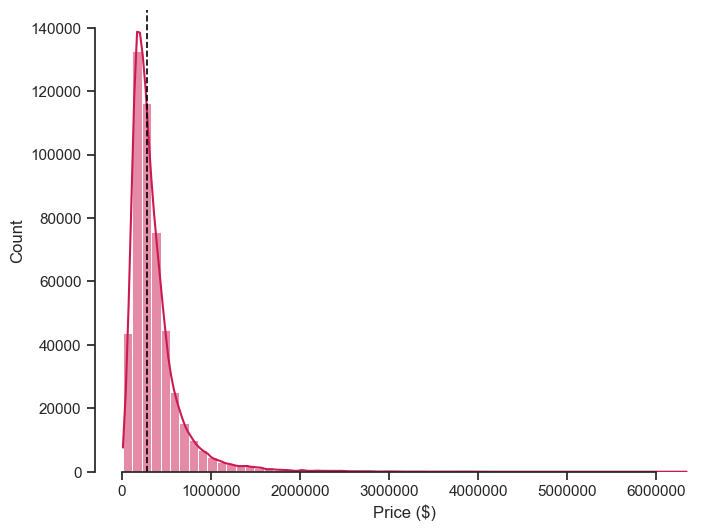

In [26]:
# Distribution of house prices across the dataset 

sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(df["price"].dropna(), bins=60, kde=True, color=sns.color_palette("rocket_r", 1)[0], ax=ax)
median_price = df["price"].median()
ax.axvline(median_price, ls="--", lw=1.2, color="black")
ax.set_xlabel("Price ($)")
ax.set_ylabel("Count")
sns.despine(trim=True)
ax.grid(False)
ax.ticklabel_format(axis="x", style="plain")
plt.show()

In [27]:
print(train_df["city_full"].isna().sum())

0
